In [181]:
import torch
from utils import solve_riccati
import numpy as np
from network import PhiNetwork, ScoreNetwork
from utils import batched_jacobian, rollout
import matplotlib.pyplot as plt

In [182]:
import matplotlib

plt.rc('font', size = 14)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [183]:
T = 1.0  # End time
n = 1    # Dimension of state space
m = 1    # Dimension of Brownian motion
N = 50000 # Number of training samples
dt = 0.02  # Time step size
steps = int(T/dt)  # Number of time steps
noise_level = 2  # Noise level in the SDE
temperature = 1.0 # Temperature for tilted distribution
uiter = 10

In [184]:
Q = torch.load(f'network/finetune_admatching_Q_timesteps{steps}_utiter{uiter}_optiter{1000}_iteration{30}_temperature{temperature}_initialQ2_updateQmu6times_lamony.pth')
mu = torch.load(f'network/finetune_admatching_mu_timesteps{steps}_utiter{uiter}_optiter{1000}_iteration{30}_temperature{temperature}_initialQ2_updateQmu6times_lamony.pth')
ut = ScoreNetwork(input_dim=n+1, out_dim=n, hidden_dim=64, num_blocks=4)
# phi_net.load_state_dict(torch.load(f'network/finetune_phi_network_timesteps{50}_iteration{100}_phiiter10_optiter3_temperature{temperature}.pth'))
ut.load_state_dict(torch.load(f'network/finetune_admatching_ut_timesteps{steps}_utiter{uiter}_optiter{1000}_iteration{30}_temperature{temperature}_initialQ2_updateQmu6times_lamony.pth'))

# ut = torch.load('network/finetune_ut_timesteps50_iteration30_phiiter10.pth')

/var/folders/pd/hp6m3j2j5v9bd6w64h7wl3rm0000gn/T/ipykernel_1444/1581028440.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  Q = torch.load(f'network/finetune_admatching_Q

<All keys matched successfully>

In [185]:
score_nn = ScoreNetwork(input_dim=n+1, out_dim=n, hidden_dim=32, num_blocks=2)
score_nn.load_state_dict(torch.load(f'network/toy_score_network_timesteps{steps}_v2.pth'))

/var/folders/pd/hp6m3j2j5v9bd6w64h7wl3rm0000gn/T/ipykernel_1444/2318091960.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  score_nn.load_state_dict(torch.load(f'network/

<All keys matched successfully>

In [186]:
def g(x):
    """
    Diffusion function of X_t for a nonlinear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Diffusion matrix. Shape (N, n, m)
    """
    B = torch.tensor([[1.0]]) * noise_level
    B = B.unsqueeze(0).repeat(x.shape[0], 1, 1)
    return B

def f(x, t, u_t=None):
    """
    Drift function of X_t for a nonlinear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
        t (torch.Tensor): torch.tensor of shape (1,): Current time
        score_nn (ScoreNetwork): Neural network for score function
        # u_t (ScoreNetwork): Neural network for feedback control law --- IGNORE ---
        u_t (torch.Tensor): control inputs at each time step for each sample. Shape (steps+1, N, m)
    Returns:
        torch.Tensor: Drift vector. Shape (N, n)
    """
    a = 2
    u = u_t(x, t.repeat(x.shape[0], 1)) if u_t is not None else torch.zeros(m)  # shape (N, m)
    gu = torch.einsum('nij,nj->ni', g(x), u)  if u_t is not None else torch.zeros_like(x) # shape (N, n)
    # u = u_t[int(t/dt)] if u_t is not None else torch.zeros((N, m))  # shape (N, m) make sure use u at the right time step
    # gu = torch.einsum('nij,nj->ni', g(x), u) # shape (N, n)
    df = a * x + noise_level**2 * score_nn(x, (T - t).repeat(x.shape[0], 1)) + gu
    return df

def special_f(x, t=None, u_t=None):
    """
    Drift function of X_t for a nonlinear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
        # u_t (ScoreNetwork): Neural network for feedback control law --- IGNORE ---
        u_t (torch.Tensor): control inputs at each time step for each sample. Shape (steps+1, N, m)
        t (torch.Tensor): Current time. Shape (1,)
    Returns:
        torch.Tensor: Drift vector. Shape (N, n)
    """
    a = 2
    u = u_t(x, (T-t).repeat(x.shape[0], 1)) if u_t is not None else torch.zeros(m)  # shape (N, m)
    gu = torch.einsum('nij,nj->ni', g(x), u)  if u_t is not None else torch.zeros_like(x) # shape (N, n)
    # u = u_t[int((T-t)/dt)] if u_t is not None else torch.zeros((N, m))  # shape (N, m) make sure use u at the right time step
    # gu = torch.einsum('nij,nj->ni', g(x), u) # shape (N, n)
    return -a * x - gu

In [187]:
# theta = (torch.randn(N, n) @ Q + mu).detach()  # shape (N, n)
theta = torch.randn(N, n) * Q + mu # shape (N, n)
W_f = torch.randn(steps + 1, N, m) * torch.sqrt(torch.tensor(dt)) # forward noise
X_f = rollout(f, g, T, dt, theta, W_f, u_t=ut).detach()  # shape (steps+1, N, n)
# X_b = rollout(special_f, g, T, dt, X_f[-1,:,:], W_f.flip(0), u_t=ut).flip(0)  # shape (steps+1, N, n)

In [188]:
print(Q, mu)

tensor([[0.9970]], requires_grad=True) tensor([0.5543], requires_grad=True)


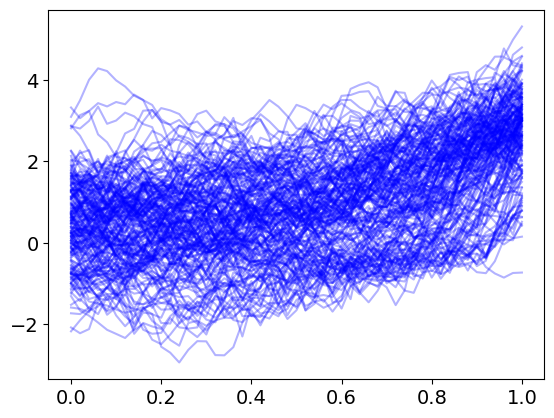

In [189]:
plt.figure()
plt.plot(np.arange(0,51)*dt, X_f[:, :200, 0].detach().numpy(), color='blue', alpha=0.3)
# plt.plot(np.arange(0,51)*dt, X_b[:, :200, 0].detach().numpy(), color='red', alpha=0.3)
plt.show()


In [190]:
def original_pdf(x):
    m1 = 3.0
    m2 = -3.0
    sigma = 1.0
    p1 = torch.exp(-0.5 * ((x - m1) / sigma)**2) / (sigma * torch.sqrt(torch.tensor(2.0) * torch.pi))
    p2 = torch.exp(-0.5 * ((x - m2) / sigma)**2) / (sigma * torch.sqrt(torch.tensor(2.0) * torch.pi))
    return 0.5 * (p1 + p2)

def tilted_pdf(x, temperature):
    return original_pdf(x)*torch.exp(-(x-3.0)**2/(2*temperature))

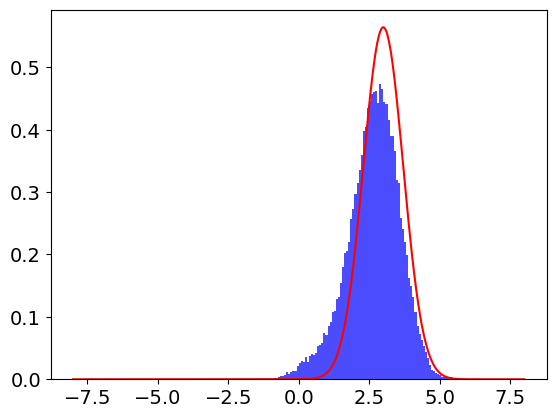

In [191]:
plt.figure()
plt.hist(X_f[-1, :, 0].detach().numpy(), bins=100, color='blue', alpha=0.7, density=True)
plotx = torch.linspace(-8, 8, 1000)
Z = torch.trapz(tilted_pdf(plotx, temperature), plotx)
q = tilted_pdf(plotx, temperature)/Z
plt.plot(plotx.numpy(), q.numpy(), label='tilted pdf', color='red')
# plt.title('Distribution of $X_T$ after Finetuning')
# plt.xlabel('$X_T$')
# plt.ylabel('Frequency')
# plt.show()
plt.savefig(f'figs/finetune_admatching_temp{temperature}.pdf', bbox_inches='tight')

In [192]:
print(f"Mean and std of X_T: {X_f[-1, :, 0].mean().item()} | {X_f[-1, :, 0].std().item()}")

Mean and std of X_T: 2.64888072013855 | 0.9243689179420471


In [193]:
# temperature_schedule = lambda k: 50.0 * (1 / 50)**(k/39) if k< 40 else 1.0  # Exponential decay schedule for temperature

In [194]:
# k = 42
# temperature = temperature_schedule(k)
# print(f"Temperature at iteration {k}: {temperature}")

In [195]:
# k = 100

In [196]:
# X_store_f = torch.load(f'data/finetune_Xf_timesteps{steps}_optiter{3}_const_temperature{temperature}_iteration{k}in100.pth')
# X_store_b = torch.load(f'data/finetune_Xb_timesteps{steps}_optiter{3}_const_temperature{temperature}_iteration{k}in100.pth')
# Y_store_b = torch.load(f'data/finetune_Yb_timesteps{steps}_optiter{3}_const_temperature{temperature}_iteration{k}in100.pth')

In [197]:
# plt.figure()
# plt.plot(np.arange(0,51)*dt, X_store_f[:, :1000, 0].detach().numpy(), color='blue', alpha=0.1)
# plt.plot(np.arange(0,51)*dt, X_store_b[:, :1000, 0].detach().numpy(), color='red', alpha=0.1)
# plt.plot(np.arange(0,51)*dt, Y_store_b[:, :1000, 0].detach().numpy(), color='green', alpha=0.1)
# plt.show()

In [198]:
# plt.figure()
# plt.hist(X_store_f[-1, :, 0].detach().numpy(), bins=100, color='blue', alpha=0.7, density=True)
# # plt.hist(X_store_b[-1, :, 0].detach().numpy(), bins=100, color='red', alpha=0.7, density=True)
# plotx = torch.linspace(-8, 8, 1000)
# Z = torch.trapz(tilted_pdf(plotx, 50), plotx)
# q = tilted_pdf(plotx, 50)/Z
# plt.plot(plotx.numpy(), q.numpy(), label='tilted pdf', color='red')
# plt.title('Distribution of $X_T$ after Finetuning')
# plt.xlabel('$X_T$')
# plt.ylabel('Frequency')
# plt.show()

In [199]:
# X_store_f[0, :, 0].mean().item(), X_store_f[0, :, 0].std().item() 

In [200]:
# X_store_f[-1, :, 0].mean().item(), X_store_f[-1, :, 0].std().item() 

In [201]:
# temperature = 50.0

In [202]:
# phi_net = ScoreNetwork(input_dim=n+1, out_dim=n, hidden_dim=64, num_blocks=4)
# phi_net.load_state_dict(torch.load(f'network/finetune_phi_network_timesteps{steps}_iteration{100}_phiiter{10}_optiter{3}_temperature{temperature}.pth'))

In [203]:
## Optimize Q and mu to further match the distribution of X_T with the tilted distribution.
# Q = torch.eye(n, requires_grad=True)  # Sigma = Q Q^T for initial distribution
# mu = torch.zeros(n, requires_grad=True)  # Mean of initial distribution
# mu_opt = torch.optim.AdamW([mu], lr=1e-3, weight_decay=1e-4)
# Q_opt = torch.optim.AdamW([Q], lr=1e-3, weight_decay=1e-4)
# for i in range(1000):
#     theta = (torch.randn(N, n) @ Q + mu).detach()  # shape (N, n)
#     mu_opt.zero_grad()
#     Q_opt.zero_grad()
#     with torch.no_grad():
#         phi_0 = phi_net(theta, torch.tensor(0.0).repeat(theta.shape[0], 1)).detach()  # shape (N, n)
#         mu_grad = phi_0.mean(dim=0)  # shape (n,)
#         temp = (theta - mu.clone().detach()) @ torch.linalg.pinv(Q.clone().detach()) # shape (N, n)
#         Q_grad = torch.einsum('nij,njk->nik', phi_0.unsqueeze(2), temp.unsqueeze(1)).mean(dim=0)  # shape (n, n)
#         mu_kl_grad = mu.clone().detach().reshape(-1)
#         Q_kl_grad = Q.clone().detach() - torch.linalg.pinv(Q.clone().detach()).T
#         mu.grad = (mu_grad + temperature*mu_kl_grad).detach()
#         Q.grad = (Q_grad + temperature*Q_kl_grad).detach()
#     mu_opt.step()
#     Q_opt.step()
#     if (i+1) % 100 == 0:
#         print(f"Iteration {i+1}, mu: {mu.detach().numpy()}, Q: {Q.detach().numpy()}, mu_grad: {mu_grad.detach().numpy()}, Q_grad: {Q_grad.detach().numpy()}, mu_kl_grad: {temperature*mu_kl_grad.detach().numpy()}, Q_kl_grad: {temperature*Q_kl_grad.detach().numpy()}")


In [204]:
# ut = UNetFromPhi(phi_net, g, temperature).eval()

In [205]:
# theta = (torch.randn(N, n) @ Q + mu).detach()  # shape (N, n)
# W_f = torch.randn(steps + 1, N, m) * torch.sqrt(torch.tensor(dt)) # forward noise
# X_f = rollout(f, g, T, dt, theta, W_f, u_t=ut)  # shape (steps+1, N, n

In [206]:
# plt.figure()
# plt.hist(X_f[-1, :, 0].detach().numpy(), bins=100, color='blue', alpha=0.7, density=True)
# plotx = torch.linspace(-8, 8, 1000)
# Z = torch.trapz(tilted_pdf(plotx, temperature), plotx)
# q = tilted_pdf(plotx, temperature)/Z
# plt.plot(plotx.numpy(), q.numpy(), label='tilted pdf', color='red')
# plt.title('Distribution of $X_T$ after Finetuning')
# plt.xlabel('$X_T$')
# plt.ylabel('Frequency')
# plt.show()

In [207]:
time_grid = torch.arange(0, steps+1) * dt

In [208]:
test = time_grid.repeat(100, 1).T

In [209]:
test.shape

torch.Size([51, 100])